# 🐑 Sheep Activity Classifier v2

**K-Fold Cross Validation + Oversampling con SMOTE-like · Kaggle Notebook**

### Cambios respecto a v1

- **K-Fold (k=5)** en lugar de split fijo del 15%
- **WeightedRandomSampler** para balancear clases en cada batch
- **Class weights** en el criterio de loss
- **Oversampling** por duplicación aumentada de clases minoritarias
- `unfreeze_blocks` reducido de 4 → 2 (menos overfitting con 100 videos)
- `dropout` aumentado de 0.4 → 0.5
- Inferencia final: modelo entrenado en **todos los datos** (sin val)

### Estructura esperada

```
/kaggle/input/<dataset>/
├── train/          # videos .mov
├── test/           # videos .mov
└── train.csv

/kaggle/input/<scripts-dataset>/
├── preprocess.py
├── dataset.py
└── model.py
```


## Carga de Dataset


In [2]:
!gdown 1K8-wcb11IbbyeKovEqb24LP30vuQOlTU

Downloading...
From (original): https://drive.google.com/uc?id=1K8-wcb11IbbyeKovEqb24LP30vuQOlTU
From (redirected): https://drive.google.com/uc?id=1K8-wcb11IbbyeKovEqb24LP30vuQOlTU&confirm=t&uuid=683c1739-86ae-4971-b96c-62b021b861f1
To: /kaggle/working/test.zip
100%|██████████████████████████████████████| 4.36G/4.36G [00:48<00:00, 89.0MB/s]


In [4]:
!unzip test.zip

Archive:  test.zip
   creating: test/
  inflating: test/0110a1cb437b4038.mov  
  inflating: test/016d9242af8f4577.mov  
  inflating: test/02b1ee35fffd48c3.mov  
  inflating: test/048667609337485b.mov  
  inflating: test/07de584e7b684894.mov  
  inflating: test/0800d01f5f6f4d5f.mov  
  inflating: test/09a42f65c05a491d.mov  
  inflating: test/0bb5c8ce46864d68.mov  
  inflating: test/0bf83d8fa4884298.mov  
  inflating: test/0dc94147ad7247e4.mov  
  inflating: test/0e3637a0fb1f4ecf.mov  
  inflating: test/0e4f890d5d9c4705.mov  
  inflating: test/0e7ad37bfac7477b.mov  
  inflating: test/0eaa862657c5431f.mov  
  inflating: test/0fdd406285bc46ce.mov  
  inflating: test/0fec0216319a4043.mov  
  inflating: test/10297ce87eca4f73.mov  
  inflating: test/10834d1a2d524234.mov  
  inflating: test/12daa379d80b40c4.mov  
  inflating: test/15dda0bd50d34c8e.mov  
  inflating: test/17abf986ab474389.mov  
  inflating: test/18519925d2ac4b94.mov  
  inflating: test/19dde3576f2541d9.mov  
  inflating: test/1

In [6]:
rm train.zip

In [3]:
ls checkpoints

best_model.pt   fold1_best.pt  fold3_best.pt  fold5_best.pt  kfold_curves.png
final_model.pt  fold2_best.pt  fold4_best.pt  history.csv    kfold_history.csv


In [49]:
cat checkpoints/kfold_history.csv

fold,epoch,lr,train_loss,train_f1,val_loss,val_f1
1,1,1e-05,2.775236407915751,0.14572872860116393,1.7858487367630005,0.2452380952380952
1,2,2e-05,2.0745020310084024,0.2815358691487724,1.686132550239563,0.2025974025974026
1,3,3e-05,2.096832791964213,0.2916433239962652,1.5745629668235779,0.3632034632034632
1,4,4e-05,1.7262239456176758,0.2700052691173668,1.2360527515411377,0.5433333333333333
1,5,5e-05,1.2796464959780376,0.5878260869565217,1.161622703075409,0.5222222222222221
1,6,5e-05,1.2778559724489849,0.5128086659883895,1.0213485956192017,0.6854545454545455
1,7,4.995922759815339e-05,1.0568076968193054,0.6802241831766864,0.9130373001098633,0.8206060606060606
1,8,4.9837043383713753e-05,1.0369771818319957,0.494270167458427,1.0247773230075836,0.6361904761904762
1,9,4.963384589619233e-05,1.1032599608103435,0.5584262067162205,1.0385339856147766,0.8095238095238095
1,10,4.935029792355834e-05,0.8254421750704447,0.7598256969076438,0.9392648339271545,0.7751515151515151
1,11,4.898732434036244e-05,1

In [24]:
!zip -r ovejas1.zip /kaggle/working/processed/train/00cf076fa17e4da5

  adding: kaggle/working/processed/train/00cf076fa17e4da5/ (stored 0%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_15.png (deflated 1%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_04.png (deflated 3%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_14.png (deflated 4%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_09.png (deflated 2%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_13.png (deflated 2%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_02.png (deflated 3%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_11.png (deflated 2%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_05.png (deflated 2%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_00.png (deflated 3%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_10.png (deflated 2%)
  adding: kaggle/working/processed/train/00cf076fa17e4da5/frame_08.png (deflate

## 0 · Instalación de dependencias


In [9]:
!pip install -q timm>=0.9.0 ultralytics>=8.0.0 albumentations einops

## 1 · GPU, imports y configuración global


In [36]:
import os, sys, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "⚠️  Activa la GPU en Settings → Accelerator."
DEVICE = torch.device("cuda")
print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch {torch.__version__} · CUDA {torch.version.cuda}")

✅ GPU : Tesla T4
   VRAM: 15.6 GB
   PyTorch 2.10.0+cu128 · CUDA 12.8


In [ ]:
# ── Rutas ─────────────────────────────────────────────────────────────
WORKING_DIR = Path("/kaggle/working")
INPUT_DIR = Path("/kaggle/input")

# Data
TRAIN_VIDEO_DIR = WORKING_DIR / "train"
TEST_VIDEO_DIR = WORKING_DIR / "test"
LABEL_CSV = INPUT_DIR / "datasets/jeffreyamc/sheep-labels/train.csv"

print(f"TRAIN_DIR: {TRAIN_VIDEO_DIR}")
print(f"TEST_DIR: {TEST_VIDEO_DIR}")
print(f"LABEL_CSV: {LABEL_CSV}")

# Scripts
MODULES_DIR = INPUT_DIR / "datasets/jeffreyamc/modules/"

print(f"MODULES_DIR {MODULES_DIR}")

PROCESSED_DIR = WORKING_DIR / "processed"
CHECKPOINT_DIR = WORKING_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Agregar scripts al path
sys.path.insert(0, str(MODULES_DIR))

# ── Hiperparámetros ────────────────────────────────────────────────────
CFG = {
    # Preprocesamiento
    "n_frames": 16,
    "video_ext": ".mov",
    # Modelo
    "num_classes": 5,
    "dropout": 0.5,  # subido de 0.4 → más regularización
    "unfreeze_blocks": 2,  # bajado de 4 → menos parámetros con 100 videos
    # K-Fold
    "n_folds": 5,
    # Entrenamiento
    "epochs": 60,
    "batch_size": 16,
    "lr": 5e-5,  # bajado levemente por dataset pequeño
    "weight_decay": 0.05,
    "warmup_epochs": 5,
    "patience": 12,
    "mixup_prob": 0.5,
    "mixup_alpha": 0.4,
    "max_grad_norm": 1.0,
    "label_smoothing": 0.1,
    "num_workers": 2,
    "seed": 42,
    # Balanceo
    "oversample": True,  # duplicar clases minoritarias con augmentation
    "use_class_weights": True,  # ponderar loss por frecuencia inversa
    # Inferencia
    "use_tta": True,
    "tta_augments": 6,  # más augmentaciones para compensar dataset pequeño
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG["seed"])
print("\nConfiguración:")
for k, v in CFG.items():
    print(f"  {k:<22} = {v}")

TRAIN_DIR: /kaggle/working/train
TEST_DIR: /kaggle/working/test
LABEL_CSV: /kaggle/input/datasets/jeffreyamc/sheep-labels/train.csv
MODULES_DIR /kaggle/input/datasets/jeffreyamc/modules

Configuración:
  n_frames               = 16
  video_ext              = .mov
  num_classes            = 5
  dropout                = 0.5
  unfreeze_blocks        = 2
  n_folds                = 5
  epochs                 = 60
  batch_size             = 16
  lr                     = 5e-05
  weight_decay           = 0.05
  warmup_epochs          = 5
  patience               = 12
  mixup_prob             = 0.5
  mixup_alpha            = 0.4
  max_grad_norm          = 1.0
  label_smoothing        = 0.1
  num_workers            = 2
  seed                   = 42
  oversample             = True
  use_class_weights      = True
  use_tta                = True
  tta_augments           = 6


## 2 · Importar módulos


In [ ]:
from preprocess import load_yolo, process_video
from dataset import SheepActivityDataset, TemporalConsistentTransform, mixup_batch
from model import SheepActivityClassifier, LabelSmoothingCrossEntropy, build_model

print("✅ Módulos importados")

✅ Módulos importados


In [46]:
import importlib
import preprocess

# Obliga a Python a leer la versión más nueva de tu dataset
importlib.reload(preprocess)

<module 'preprocess' from '/kaggle/input/datasets/jeffreyamc/modules/preprocess.py'>

## 3 · Preprocesamiento de videos


In [51]:
yolo = load_yolo("yolov8m.pt")

print("✅ YOLO listo")

[YOLO] Cargando modelo yolov8m.pt...
[INFO] ¡GPU detectada! Moviendo modelo a CUDA.
✅ YOLO está en la GPU
✅ YOLO listo


In [ ]:
def preprocess_split(video_dir, split, yolo_model, n_frames=16, video_ext=".mov"):
    out_root = PROCESSED_DIR / split
    video_files = sorted(video_dir.glob(f"*{video_ext}"))
    if not video_files:
        video_files = sorted(video_dir.glob("*.mp4"))
    print(f"\n[{split.upper()}] {len(video_files)} videos → {out_root}")
    for vf in tqdm(video_files, desc=f"Preprocesando {split}"):
        out_dir = out_root / vf.stem
        if out_dir.exists() and len(list(out_dir.glob("*.png"))) == n_frames:
            continue
        process_video(str(vf), yolo_model, str(out_dir), vf.stem, n_frames)
    print("  ✅ Listo")


# preprocess_split(TRAIN_VIDEO_DIR, "train", yolo, CFG["n_frames"], CFG["video_ext"])
preprocess_split(TEST_VIDEO_DIR, "test", yolo, CFG["n_frames"], CFG["video_ext"])

del yolo
torch.cuda.empty_cache()
print("\n🧹 YOLO liberado de memoria")


[TEST] 169 videos → /kaggle/working/processed/test


Preprocesando test:   0%|          | 0/169 [00:00<?, ?it/s]

  ✅ Listo

🧹 YOLO liberado de memoria


## 4 · Balanceo de clases


In [ ]:
# ── Cargar etiquetas ───────────────────────────────────────────────────
df = pd.read_csv(LABEL_CSV)
df.columns = ["Id", "Target"]

print("Distribución original:")
counts = df["Target"].value_counts().sort_index()
for cls, cnt in counts.items():
    bar = "█" * cnt
    print(f"  Clase {cls}: {cnt:3d} videos  {bar}")

# ── Oversampling: duplicar clases por debajo de la media ──────────────
# Estrategia: para cada clase con menos muestras que el target,
# duplicamos sus filas en el DataFrame de train. El Dataset aplicará
# augmentation diferente en cada paso, por lo que no son copias exactas.


def oversample_df(df: pd.DataFrame, strategy: str = "median") -> pd.DataFrame:
    """
    Duplica filas de clases minoritarias hasta alcanzar la mediana (o máximo).
    Como el Dataset aplica augmentation aleatoria, cada copia recibe
    una transformación distinta → no son duplicados exactos.
    """
    counts = df["Target"].value_counts()
    if strategy == "median":
        target_n = int(counts.median())
    else:  # max
        target_n = int(counts.max())

    parts = [df]
    for cls, cnt in counts.items():
        if cnt < target_n:
            deficit = target_n - cnt
            cls_rows = df[df["Target"] == cls]
            extra = cls_rows.sample(n=deficit, replace=True, random_state=42)
            parts.append(extra)
            print(
                f"  Clase {cls}: {cnt} → {cnt + deficit} (+{deficit} muestras oversampled)"
            )

    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )


# ── Class weights para el loss ─────────────────────────────────────────
def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Peso inversamente proporcional a la frecuencia de cada clase."""
    counts = df["Target"].value_counts().sort_index()
    total = len(df)
    weights = torch.tensor(
        [total / (num_classes * counts.get(i, 1)) for i in range(num_classes)],
        dtype=torch.float32,
    )
    weights = weights / weights.sum() * num_classes  # normalizar
    return weights


class_weights = compute_class_weights(df, CFG["num_classes"])
print(f"\nClass weights: {class_weights.numpy().round(3)}")

Distribución original:
  Clase 0:  22 videos  ██████████████████████
  Clase 1:  13 videos  █████████████
  Clase 2:  28 videos  ████████████████████████████
  Clase 3:  29 videos  █████████████████████████████
  Clase 4:   8 videos  ████████

Class weights: [      0.716       1.211       0.562       0.543       1.968]


## 5 · Utilidades de entrenamiento


In [ ]:
def cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        progress = float(epoch - warmup_epochs) / float(
            max(1, total_epochs - warmup_epochs)
        )
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return LambdaLR(optimizer, lr_lambda)


class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best = None

    def step(self, score):
        if self.best is None or score > self.best + self.min_delta:
            self.best = score
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def make_weighted_sampler(dataset_labels: list) -> WeightedRandomSampler:
    """
    WeightedRandomSampler: cada batch tiene probabilidad uniforme de
    contener ejemplos de cualquier clase, sin importar el desbalance.
    """
    counts = Counter(dataset_labels)
    weights = [1.0 / counts[lbl] for lbl in dataset_labels]
    return WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True,
    )


def build_optimizer(model):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "bias" in name or "norm" in name:
            no_decay.append(param)
        else:
            decay.append(param)
    return AdamW(
        [
            {"params": decay, "weight_decay": CFG["weight_decay"]},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=CFG["lr"],
        betas=(0.9, 0.999),
    )


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Train", leave=False):
        clips = batch["clip"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        use_mixup = np.random.random() < CFG["mixup_prob"]
        if use_mixup:
            clips, labels_soft = mixup_batch(
                clips, labels, CFG["num_classes"], CFG["mixup_alpha"]
            )

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            logits = model(clips)
            loss = criterion(logits, labels_soft if use_mixup else labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["max_grad_norm"])
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch["label"].numpy())

    return {
        "loss": total_loss / len(loader),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
    }


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Val  ", leave=False):
        clips = batch["clip"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)
        with autocast("cuda"):
            logits = model(clips)
            loss = criterion(logits, labels)
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1_per = f1_score(all_labels, all_preds, average=None, zero_division=0)
    return {
        "loss": total_loss / len(loader),
        "macro_f1": float(f1_per.mean()),
        "f1_per_class": f1_per.tolist(),
        "preds": all_preds,
        "labels": all_labels,
    }


print("✅ Funciones definidas")

✅ Funciones definidas


## 6 · Entrenamiento con K-Fold Cross Validation


In [ ]:
# ── K-Fold sobre el DataFrame ORIGINAL (sin oversample) ───────────────
# El oversample se aplica SOLO dentro de cada fold de train,
# nunca al fold de validación (para no contaminar la métrica)

skf = StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=CFG["seed"])

fold_results = []  # F1 de cada fold
fold_histories = []  # curvas de pérdida por fold
best_checkpoints = []  # path del mejor checkpoint de cada fold

print(f"{'='*65}")
print(f"  K-Fold: {CFG['n_folds']} folds | Epochs: {CFG['epochs']} | LR: {CFG['lr']}")
print(
    f"  Balanceo: oversample={CFG['oversample']} | class_weights={CFG['use_class_weights']}"
)
print(f"{'='*65}")

for fold, (train_idx, val_idx) in enumerate(skf.split(df["Id"], df["Target"])):
    print(f"\n{'─'*65}")
    print(f"  FOLD {fold+1}/{CFG['n_folds']}")
    print(f"{'─'*65}")

    # ── DataFrames del fold ──────────────────────────────────────────
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    print(f"  Train: {len(train_df)} | Val: {len(val_df)}")
    print(f"  Val clases: {dict(val_df['Target'].value_counts().sort_index())}")

    # ── Oversample en train (nunca en val) ───────────────────────────
    if CFG["oversample"]:
        train_df_os = oversample_df(train_df, strategy="median")
        print(f"  Train tras oversample: {len(train_df_os)}")
    else:
        train_df_os = train_df

    # ── Datasets ─────────────────────────────────────────────────────
    train_ds = SheepActivityDataset(
        str(PROCESSED_DIR / "train"), train_df_os, CFG["n_frames"], is_train=True
    )
    val_ds = SheepActivityDataset(
        str(PROCESSED_DIR / "train"), val_df, CFG["n_frames"], is_train=False
    )

    # ── WeightedRandomSampler para balancear batches ──────────────────
    train_labels = train_df_os["Target"].tolist()
    sampler = make_weighted_sampler(train_labels)

    train_loader = DataLoader(
        train_ds,
        batch_size=CFG["batch_size"],
        sampler=sampler,  # reemplaza shuffle=True
        num_workers=CFG["num_workers"],
        pin_memory=True,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=CFG["batch_size"],
        shuffle=False,
        num_workers=CFG["num_workers"],
        pin_memory=True,
    )

    # ── Modelo fresco para cada fold ──────────────────────────────────
    set_seed(CFG["seed"] + fold)
    model = build_model(
        num_classes=CFG["num_classes"],
        n_frames=CFG["n_frames"],
        dropout=CFG["dropout"],
        unfreeze_last_n_blocks=CFG["unfreeze_blocks"],
        device="cuda",
    )
    if torch.__version__ >= "2.0.0":
        try:
            model = torch.compile(model, mode="reduce-overhead")
        except Exception:
            pass

    # ── Criterio con class weights ────────────────────────────────────
    if CFG["use_class_weights"]:
        # Recalcular weights sobre el fold de train
        fold_weights = compute_class_weights(train_df, CFG["num_classes"]).to(DEVICE)
        criterion = LabelSmoothingCrossEntropy(
            smoothing=CFG["label_smoothing"],
            num_classes=CFG["num_classes"],
        )
        # Parchamos el criterio para usar class_weight en el loss base
        # Usamos CrossEntropyLoss con weight como auxiliar para val
        ce_weighted = nn.CrossEntropyLoss(weight=fold_weights)
    else:
        criterion = LabelSmoothingCrossEntropy(
            smoothing=CFG["label_smoothing"],
            num_classes=CFG["num_classes"],
        )

    optimizer = build_optimizer(model)
    scheduler = cosine_warmup_scheduler(optimizer, CFG["warmup_epochs"], CFG["epochs"])
    scaler = GradScaler("cuda")
    early_stop = EarlyStopping(patience=CFG["patience"])

    best_f1 = 0.0
    best_path = CHECKPOINT_DIR / f"fold{fold+1}_best.pt"
    history = []

    for epoch in range(1, CFG["epochs"] + 1):
        lr_now = optimizer.param_groups[0]["lr"]
        train_m = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_m = validate(model, val_loader, criterion)
        scheduler.step()

        history.append(
            {
                "fold": fold + 1,
                "epoch": epoch,
                "lr": lr_now,
                "train_loss": train_m["loss"],
                "train_f1": train_m["macro_f1"],
                "val_loss": val_m["loss"],
                "val_f1": val_m["macro_f1"],
            }
        )

        tag = "  ✓ BEST" if val_m["macro_f1"] > best_f1 else ""
        print(
            f"  Ep {epoch:3d} | lr={lr_now:.1e} | "
            f"Tr L={train_m['loss']:.3f} F1={train_m['macro_f1']:.3f} | "
            f"Va L={val_m['loss']:.3f} F1={val_m['macro_f1']:.3f}{tag}"
        )
        print(f"    F1/clase: {[f'{v:.2f}' for v in val_m['f1_per_class']]}")

        if val_m["macro_f1"] > best_f1:
            best_f1 = val_m["macro_f1"]
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "val_f1": best_f1,
                    "cfg": CFG,
                },
                best_path,
            )

        if early_stop.step(val_m["macro_f1"]):
            print(f"  ⏹  Early stop en época {epoch}")
            break

    fold_results.append(best_f1)
    fold_histories.extend(history)
    best_checkpoints.append(str(best_path))
    print(f"\n  📊 Fold {fold+1} → Best Val F1 = {best_f1:.4f}")
    torch.cuda.empty_cache()

print(f"\n{'='*65}")
print(f"  K-Fold completo")
for i, f1 in enumerate(fold_results):
    print(f"  Fold {i+1}: {f1:.4f}")
print(f"  Media  : {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
print(f"{'='*65}")

  K-Fold: 5 folds | Epochs: 60 | LR: 5e-05
  Balanceo: oversample=True | class_weights=True

─────────────────────────────────────────────────────────────────
  FOLD 1/5
─────────────────────────────────────────────────────────────────
  Train: 80 | Val: 20
  Val clases: {0: np.int64(5), 1: np.int64(2), 2: np.int64(5), 3: np.int64(6), 4: np.int64(2)}
  Clase 1: 11 → 17 (+6 muestras oversampled)
  Clase 4: 6 → 17 (+11 muestras oversampled)
  Train tras oversample: 97
[Dataset] 97 samples cargados (is_train=True)
[Dataset] 20 samples cargados (is_train=False)
[Model] Parámetros totales: 85,798,656 | Entrenables: 14,177,280 (16.5%)


  Train:   0%|          | 0/6 [00:00<?, ?it/s]

  Val  :   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   1 | lr=1.0e-05 | Tr L=2.775 F1=0.146 | Va L=1.786 F1=0.245  ✓ BEST
    F1/clase: ['0.50', '0.25', '0.33', '0.14', '0.00']


  Train:   0%|          | 0/6 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/2 [00:00<?, ?it/s]

  Ep  23 | lr=3.9e-05 | Tr L=1.268 F1=0.748 | Va L=0.562 F1=1.000
    F1/clase: ['1.00', '1.00', '1.00', '1.00', '1.00']


  Train:   0%|          | 0/6 [00:00<?, ?it/s]

  Val  :   0%|          | 0/2 [00:00<?, ?it/s]

  Ep  24 | lr=3.8e-05 | Tr L=0.872 F1=0.693 | Va L=0.568 F1=1.000
    F1/clase: ['1.00', '1.00', '1.00', '1.00', '1.00']
  ⏹  Early stop en época 24

  📊 Fold 5 → Best Val F1 = 1.0000

  K-Fold completo
  Fold 1: 0.8206
  Fold 2: 1.0000
  Fold 3: 0.8248
  Fold 4: 1.0000
  Fold 5: 1.0000
  Media  : 0.9291 ± 0.0869


## 7 · Curvas de entrenamiento por fold


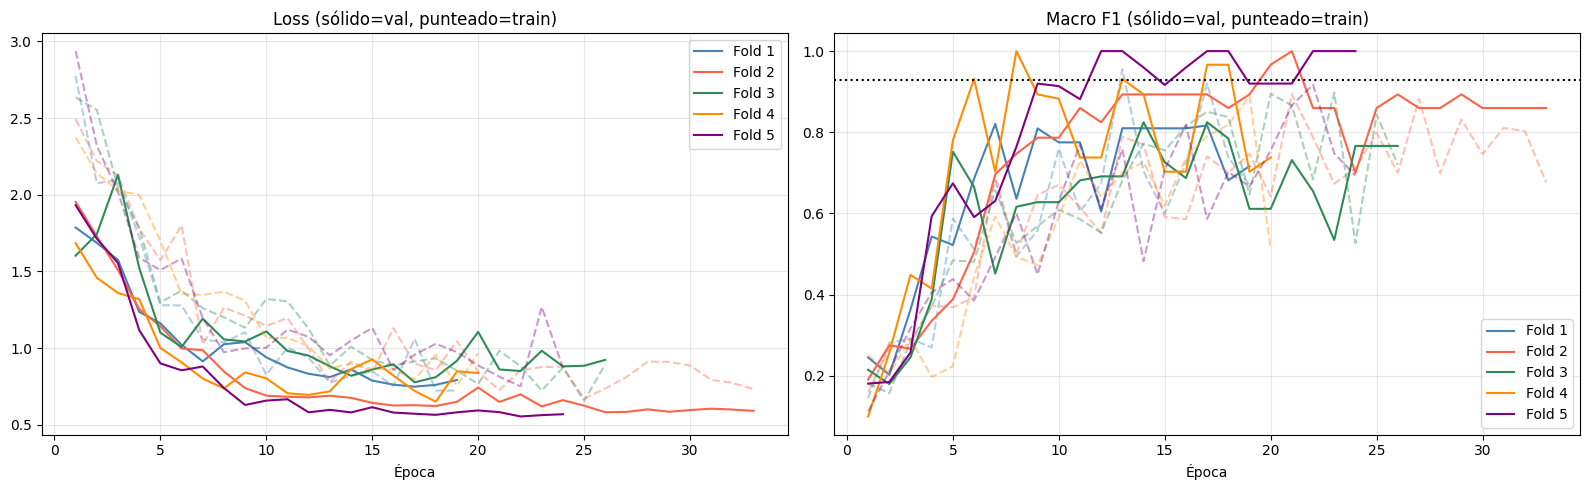

K-Fold Val F1: 0.9291 ± 0.0869


In [ ]:
hist_df = pd.DataFrame(fold_histories)
hist_df.to_csv(CHECKPOINT_DIR / "kfold_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["steelblue", "tomato", "seagreen", "darkorange", "purple"]

for fold_n in range(1, CFG["n_folds"] + 1):
    fd = hist_df[hist_df["fold"] == fold_n]
    c = colors[fold_n - 1]
    axes[0].plot(fd["epoch"], fd["train_loss"], color=c, alpha=0.4, linestyle="--")
    axes[0].plot(fd["epoch"], fd["val_loss"], color=c, label=f"Fold {fold_n}")
    axes[1].plot(fd["epoch"], fd["train_f1"], color=c, alpha=0.4, linestyle="--")
    axes[1].plot(fd["epoch"], fd["val_f1"], color=c, label=f"Fold {fold_n}")

axes[0].set_title("Loss (sólido=val, punteado=train)")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Macro F1 (sólido=val, punteado=train)")
axes[1].set_xlabel("Época")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(
    np.mean(fold_results),
    color="black",
    linestyle=":",
    label=f"Media={np.mean(fold_results):.3f}",
)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "kfold_curves.png", dpi=120)
plt.show()
print(f"K-Fold Val F1: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")

## 8 · Entrenamiento final sobre TODOS los datos

Una vez validado el K-Fold, entrenamos un modelo final con el 100% de los datos de train (sin fold de val) para maximizar el rendimiento en el test de la competencia.


In [ ]:
# ── DataFrame con todos los datos + oversample ────────────────────────
print("Entrenamiento final sobre 100% de los datos...")
if CFG["oversample"]:
    full_df = oversample_df(df, strategy="median")
    print(f"Muestras tras oversample: {len(full_df)}")
else:
    full_df = df

full_ds = SheepActivityDataset(
    str(PROCESSED_DIR / "train"), full_df, CFG["n_frames"], is_train=True
)
full_sampler = make_weighted_sampler(full_df["Target"].tolist())
full_loader = DataLoader(
    full_ds,
    batch_size=CFG["batch_size"],
    sampler=full_sampler,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    drop_last=True,
)

# ── Número de épocas: media de épocas óptimas en los folds ───────────
hist_df = pd.DataFrame(fold_histories)
best_epochs = hist_df.loc[hist_df.groupby("fold")["val_f1"].idxmax(), "epoch"]
final_epochs = max(10, int(best_epochs.mean()))
print(
    f"Épocas óptimas por fold: {best_epochs.tolist()} → entrenando {final_epochs} épocas"
)

# ── Modelo final ──────────────────────────────────────────────────────
set_seed(CFG["seed"])
final_model = build_model(
    num_classes=CFG["num_classes"],
    n_frames=CFG["n_frames"],
    dropout=CFG["dropout"],
    unfreeze_last_n_blocks=CFG["unfreeze_blocks"],
    device="cuda",
)
if torch.__version__ >= "2.0.0":
    try:
        final_model = torch.compile(final_model, mode="reduce-overhead")
    except Exception:
        pass

final_criterion = LabelSmoothingCrossEntropy(CFG["label_smoothing"], CFG["num_classes"])
final_optimizer = build_optimizer(final_model)
final_scheduler = cosine_warmup_scheduler(
    final_optimizer, CFG["warmup_epochs"], final_epochs
)
final_scaler = GradScaler("cuda")
final_history = []
FINAL_PATH = CHECKPOINT_DIR / "final_model.pt"

print(f"\n{'='*55}")
print(f"  Entrenamiento final: {final_epochs} épocas")
print(f"{'='*55}")

for epoch in range(1, final_epochs + 1):
    lr_now = final_optimizer.param_groups[0]["lr"]
    train_m = train_one_epoch(
        final_model, full_loader, final_optimizer, final_criterion, final_scaler
    )
    final_scheduler.step()
    final_history.append({"epoch": epoch, "lr": lr_now, **train_m})
    print(
        f"  Ep {epoch:3d} | lr={lr_now:.1e} | Loss={train_m['loss']:.4f} | F1={train_m['macro_f1']:.4f}"
    )

torch.save(
    {
        "epoch": final_epochs,
        "model_state": final_model.state_dict(),
        "cfg": CFG,
    },
    FINAL_PATH,
)
print(f"\n💾 Modelo final guardado: {FINAL_PATH}")

Entrenamiento final sobre 100% de los datos...
  Clase 1: 13 → 22 (+9 muestras oversampled)
  Clase 4: 8 → 22 (+14 muestras oversampled)
Muestras tras oversample: 123
[Dataset] 123 samples cargados (is_train=True)
Épocas óptimas por fold: [7, 21, 14, 8, 12] → entrenando 12 épocas
[Model] Parámetros totales: 85,798,656 | Entrenables: 14,177,280 (16.5%)

  Entrenamiento final: 12 épocas


  Train:   0%|          | 0/7 [00:00<?, ?it/s]

  Ep   1 | lr=1.0e-05 | Loss=2.6281 | F1=0.1290


  Train:   0%|          | 0/7 [00:00<?, ?it/s]

  Ep   2 | lr=2.0e-05 | Loss=2.3243 | F1=0.1839


...

  Ep  10 | lr=1.9e-05 | Loss=1.1179 | F1=0.6217


  Train:   0%|          | 0/7 [00:00<?, ?it/s]

  Ep  11 | lr=9.4e-06 | Loss=1.0801 | F1=0.7910


  Train:   0%|          | 0/7 [00:00<?, ?it/s]

  Ep  12 | lr=2.5e-06 | Loss=1.0620 | F1=0.6435

💾 Modelo final guardado: /kaggle/working/checkpoints/final_model.pt


## 9 · Inferencia con ensemble K-Fold + TTA


In [ ]:
# Cargamos TODOS los checkpoints: 5 folds + modelo final
# y promediamos sus probabilidades (ensemble)


def load_inference_model(ckpt_path: str) -> SheepActivityClassifier:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    cfg_ = ckpt.get("cfg", CFG)
    m = SheepActivityClassifier(
        num_classes=cfg_["num_classes"],
        n_frames=cfg_["n_frames"],
        dropout=0.0,
        unfreeze_last_n_blocks=cfg_["unfreeze_blocks"],
        use_temporal_attention=True,
    ).to(DEVICE)
    state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
    m.load_state_dict(state, strict=False)
    m.eval()
    return m


# Cargar todos los modelos
FINAL_PATH = CHECKPOINT_DIR / "final_model.pt"
best_checkpoints = [
    str(CHECKPOINT_DIR / "fold2_best.pt"),
    str(CHECKPOINT_DIR / "fold4_best.pt"),
    str(CHECKPOINT_DIR / "fold5_best.pt"),
]
all_ckpts = best_checkpoints + [str(FINAL_PATH)]
ensemble_models = []
for ckpt_path in all_ckpts:
    m = load_inference_model(ckpt_path)
    ensemble_models.append(m)
    print(f"  ✅ Cargado: {Path(ckpt_path).name}")

torch.backends.cudnn.benchmark = True
print(f"\nEnsemble de {len(ensemble_models)} modelos listo")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[Model] Parámetros totales: 85,798,656 | Entrenables: 14,177,280 (16.5%)
  ✅ Cargado: fold2_best.pt
[Model] Parámetros totales: 85,798,656 | Entrenables: 14,177,280 (16.5%)
  ✅ Cargado: fold4_best.pt
[Model] Parámetros totales: 85,798,656 | Entrenables: 14,177,280 (16.5%)
  ✅ Cargado: fold5_best.pt
[Model] Parámetros totales: 85,798,656 | Entrenables: 14,177,280 (16.5%)
  ✅ Cargado: final_model.pt

Ensemble de 4 modelos listo


In [ ]:
# ── Dataset de test ───────────────────────────────────────────────────
test_ds = SheepActivityDataset(
    str(PROCESSED_DIR / "test"),
    labels_df=None,
    n_frames=CFG["n_frames"],
    is_train=False,
)
print(f"Test videos: {len(test_ds)}")


def predict_with_tta(models: list, frames_pil: list, n_augments: int) -> np.ndarray:
    """Ensemble de modelos + TTA → promedia softmax de todos."""
    all_probs = []
    tf_val = TemporalConsistentTransform(is_train=False)
    tf_aug = TemporalConsistentTransform(is_train=True)

    for model in models:
        # 1 pase sin aug
        clip = tf_val(frames_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad(), autocast("cuda"):
            all_probs.append(F.softmax(model(clip), dim=-1).cpu().numpy())
        # n_augments-1 pases con aug
        for _ in range(n_augments - 1):
            clip = tf_aug(frames_pil).unsqueeze(0).to(DEVICE)
            with torch.no_grad(), autocast("cuda"):
                all_probs.append(F.softmax(model(clip), dim=-1).cpu().numpy())

    return np.mean(all_probs, axis=0)  # (1, num_classes)


# ── Inferencia ────────────────────────────────────────────────────────
results = []
for idx in tqdm(range(len(test_ds)), desc="Inferencia TTA + Ensemble"):
    video_id = test_ds.samples[idx][0]
    frames = test_ds._load_frames(video_id)
    probs = predict_with_tta(ensemble_models, frames, CFG["tta_augments"])
    pred = int(probs.argmax(axis=-1)[0])
    results.append({"Id": video_id, "Predicted": pred})

submission = pd.DataFrame(results)
print(f"\n✅ {len(submission)} predicciones")
print("Distribución:", dict(submission["Predicted"].value_counts().sort_index()))

[Dataset] 169 videos de test
Test videos: 169


Inferencia TTA + Ensemble:   0%|          | 0/169 [00:00<?, ?it/s]


✅ 169 predicciones
Distribución: {0: np.int64(50), 1: np.int64(21), 2: np.int64(50), 3: np.int64(43), 4: np.int64(5)}


In [60]:
SUBMISSION_PATH = WORKING_DIR / "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

# Validación del formato
df_check = pd.read_csv(SUBMISSION_PATH)
assert list(df_check.columns) == ["Id", "Predicted"]
assert df_check["Predicted"].between(0, 4).all()
assert df_check["Id"].nunique() == len(df_check)
assert df_check.isnull().sum().sum() == 0

print(f"✅ Submission válido")
print(f"   Filas  : {len(df_check)}")
print(f"   Clases : {sorted(df_check['Predicted'].unique())}")
print(f"💾 Guardado: {SUBMISSION_PATH}")
submission.head(10)

✅ Submission válido
   Filas  : 169
   Clases : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
💾 Guardado: /kaggle/working/submission.csv


,Id,Predicted
0,0110a1cb437b4038,1
1,016d9242af8f4577,3
2,02b1ee35fffd48c3,0
3,048667609337485b,3
4,07de584e7b684894,3
5,0800d01f5f6f4d5f,2
6,09a42f65c05a491d,2
7,0bb5c8ce46864d68,3
8,0bf83d8fa4884298,0
9,0dc94147ad7247e4,2
